In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix, accuracy_score
import sklearn.metrics as metrics

In [3]:
filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillUp/labs/ML-FinalAssignment/Weather_Data.csv"
df = pd.read_csv(filepath)

In [4]:
df.head()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2/1/2008,19.5,22.4,15.6,6.2,0.0,W,41,S,SSW,...,92,84,1017.6,1017.4,8,8,20.7,20.9,Yes,Yes
1,2/2/2008,19.5,25.6,6.0,3.4,2.7,W,41,W,E,...,83,73,1017.9,1016.4,7,7,22.4,24.8,Yes,Yes
2,2/3/2008,21.6,24.5,6.6,2.4,0.1,W,41,ESE,ESE,...,88,86,1016.7,1015.6,7,8,23.5,23.0,Yes,Yes
3,2/4/2008,20.2,22.8,18.8,2.2,0.0,W,41,NNE,E,...,83,90,1014.2,1011.8,8,8,21.4,20.9,Yes,Yes
4,2/5/2008,19.7,25.7,77.4,4.8,0.0,W,41,NNE,W,...,88,74,1008.3,1004.8,8,8,22.5,25.5,Yes,Yes


In [5]:
#dummy variables

df_sydney_processed = pd.get_dummies(data=df, columns=['RainToday', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])

In [6]:
#yes=1, no=0

df_sydney_processed.replace(['No', 'Yes'], [0,1], inplace=True)

In [7]:
df_sydney_processed.drop('Date',axis=1,inplace=True) #get rid of date column

In [8]:
df_sydney_processed = df_sydney_processed.astype(float)

In [11]:
# X and Y

X = df_sydney_processed.drop(columns='RainTomorrow', axis=1) #X
Y = df_sydney_processed['RainTomorrow'] #Y

In [ ]:
#(1) split data into training and testing sets

In [12]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=10)

In [ ]:
#(2)

In [25]:
#import linear model from sklearn and fit model
from sklearn import linear_model

lin_reg=linear_model.LinearRegression()

model_1=lin_reg.fit(x_train,y_train)

In [26]:
import plotly.express as px

In [27]:
X.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday_No', 'RainToday_Yes', 'WindGustDir_E',
       'WindGustDir_ENE', 'WindGustDir_ESE', 'WindGustDir_N', 'WindGustDir_NE',
       'WindGustDir_NNE', 'WindGustDir_NNW', 'WindGustDir_NW', 'WindGustDir_S',
       'WindGustDir_SE', 'WindGustDir_SSE', 'WindGustDir_SSW',
       'WindGustDir_SW', 'WindGustDir_W', 'WindGustDir_WNW', 'WindGustDir_WSW',
       'WindDir9am_E', 'WindDir9am_ENE', 'WindDir9am_ESE', 'WindDir9am_N',
       'WindDir9am_NE', 'WindDir9am_NNE', 'WindDir9am_NNW', 'WindDir9am_NW',
       'WindDir9am_S', 'WindDir9am_SE', 'WindDir9am_SSE', 'WindDir9am_SSW',
       'WindDir9am_SW', 'WindDir9am_W', 'WindDir9am_WNW', 'WindDir9am_WSW',
       'WindDir3pm_E', 'WindDir3pm_ENE', 'WindDir3pm_ESE', 'WindDir3pm_N',
       'WindDir3pm_NE', 

In [28]:
y=df['RainTomorrow']


In [31]:
#predictions
y_hat_1=model_1.predict(x_test)
y_hat_1

array([ 1.31927490e-01,  2.76077271e-01,  9.78149414e-01,  2.87460327e-01,
        1.32339478e-01,  4.60342407e-01,  3.56857300e-01,  8.56338501e-01,
        6.75018311e-01,  3.84063721e-02,  4.85229492e-03,  2.81280518e-01,
        3.39141846e-01,  7.80792236e-02,  6.25915527e-02,  5.64392090e-01,
       -6.14166260e-02,  5.24108887e-01,  1.53717041e-01,  3.59695435e-01,
        6.05468750e-02,  9.03564453e-01,  4.67544556e-01,  2.03338623e-01,
       -7.10449219e-02,  3.83758545e-01,  5.36071777e-01, -2.29034424e-02,
        6.40258789e-01, -9.57489014e-02,  3.78128052e-01,  1.20330811e-01,
       -1.81579590e-02,  5.54809570e-02,  5.63461304e-01,  1.06292725e+00,
       -6.77490234e-03,  5.14404297e-01, -8.83789062e-02,  6.92138672e-02,
        2.45208740e-02,  8.71704102e-01,  2.44689941e-01,  3.94775391e-01,
        2.67593384e-01,  4.46807861e-01, -4.75158691e-02,  1.89468384e-01,
        7.76611328e-01,  1.57775879e-01,  3.86047363e-03, -5.19561768e-02,
        2.07412720e-01, -

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [45]:
LinearRegression_MAE = mean_absolute_error(y_test,y_hat_1)
LinearRegression_MSE = mean_squared_error(y_test,y_hat_1)
LinearRegression_R2 = r2_score(y_test,y_hat_1)

print("MAE: ", LinearRegression_MAE)
print("MSE: ", LinearRegression_MSE)
print("R2: ", LinearRegression_R2)

MAE:  0.2563250126729485
MSE:  0.1157232929703616
R2:  0.4271186909603826


In [50]:
# (3) regression report/table
report_1={
"Metric" : ["MAE","MSE","R2"],
"Score" : [LinearRegression_MAE,LinearRegression_MSE,LinearRegression_R2]
}

In [51]:
Regression_report=pd.DataFrame(data=report_1)

Regression_report

,Metric,Score
0,MAE,0.256325
1,MSE,0.115723
2,R2,0.427119


In [52]:
#(4) knn 
from sklearn.neighbors import KNeighborsClassifier as KNC



In [53]:
k=4

#train model and predict

neighbor=KNC(n_neighbors=k).fit(x_train,y_train)
neighbor

KNeighborsClassifier(n_neighbors=4)

In [54]:
#predictions
y_hat_knn=neighbor.predict(x_test)

In [55]:
from sklearn import metrics

In [56]:
knn_accuracy=metrics.accuracy_score(y_test,y_hat_knn)
knn_jaccard=metrics.jaccard_score(y_test,y_hat_knn)
knn_f1=metrics.f1_score(y_test,y_hat_knn)

In [57]:
report_2={
    "Metric" : ["Accuracy","Jaccard","F1"],
    "Score" : [knn_accuracy,knn_jaccard,knn_f1]
}

knn_report=pd.DataFrame(data=report_2)

knn_report

,Metric,Score
0,Accuracy,0.818321
1,Jaccard,0.425121
2,F1,0.596610


In [59]:
#(5) decision trees
# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor


In [61]:
sklearn_dt = DecisionTreeRegressor(max_depth=8, random_state=35)

sklearn_dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

In [62]:
yhat_dt = sklearn_dt.predict(x_test)

In [63]:
#performance metrics
dt_mse=mean_squared_error(y_test,yhat_dt)
dt_mae=mean_absolute_error(y_test,yhat_dt)
dt_r2=r2_score(y_test,yhat_dt)


In [64]:
report_3={
    "Metric" : ["MAE","MSE","R2"],
    "Score" : [dt_mse,dt_mae,dt_r2]
}
report_3

{'Metric': ['MAE', 'MSE', 'R2'],
 'Score': [0.17123082836570033, 0.23873255647593444, 0.15233192398695417]}

In [65]:
#(6) logistic regression
X_logistic=preprocessing.StandardScaler().fit(X).transform(X)

In [66]:
x_train_1,x_test_1,y_train,y_test=train_test_split(X_logistic,Y,test_size=0.2,random_state=10)

In [67]:
x_train_1.shape

(2616, 66)

In [69]:
y_train.shape

(2616,)

In [70]:
from sklearn.metrics import confusion_matrix

In [72]:
LR=LogisticRegression(C=0.01,solver='liblinear').fit(x_train_1,y_train)
LR

LogisticRegression(C=0.01, solver='liblinear')

In [73]:
yhat_lr=LR.predict(x_test_1)

In [75]:
yhat_lr_prob=LR.predict_proba(x_test_1)
yhat_lr_prob

array([[0.879301  , 0.120699  ],
       [0.70283344, 0.29716656],
       [0.06137274, 0.93862726],
       ...,
       [0.24760847, 0.75239153],
       [0.82559063, 0.17440937],
       [0.58382118, 0.41617882]])

In [77]:
jaccard_score(yhat_lr,y_test)

0.5426008968609866

In [80]:
#Confusion matrix

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat_lr, labels=[1,0]))

[[121  63]
 [ 39 432]]


Confusion matrix, without normalization
[[121  63]
 [ 39 432]]


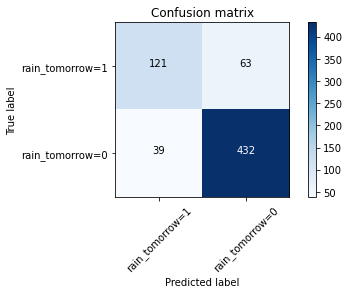

In [85]:
 # Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat_lr, labels=[1,0])
np.set_printoptions(precision=2)
# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['rain_tomorrow=1','rain_tomorrow=0'],
                      normalize= False, 
                      title='Confusion matrix',
                        cmap=plt.cm.Blues)

In [87]:
#(7) SVM 

classify=svm.SVC(kernel='rbf')

Y_new=np.asarray(Y)

x_train_1,x_test_1,y_train,y_test=train_test_split(X,Y_new,test_size=0.2,random_state=10)


classify.fit(x_train,y_train)


SVC()

In [88]:
yhat_svm = classify.predict(x_test)

              precision    recall  f1-score   support

         0.0       0.72      1.00      0.84       471
         1.0       0.00      0.00      0.00       184

    accuracy                           0.72       655
   macro avg       0.36      0.50      0.42       655
weighted avg       0.52      0.72      0.60       655

Confusion matrix, without normalization
[[121  63]
 [ 39 432]]


C:\Users\jdspr\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\jdspr\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\jdspr\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1245: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



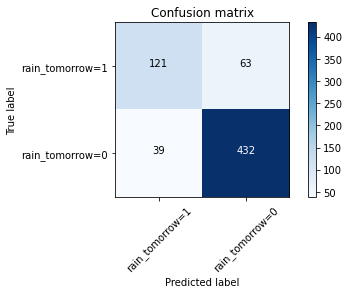

In [92]:
 # Compute confusion matrix

np.set_printoptions(precision=2)
print(classification_report(y_test, yhat_svm))
# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['rain_tomorrow=1','rain_tomorrow=0'],
                      normalize= False, 
                      title='Confusion matrix',
                        cmap=plt.cm.Blues)

In [94]:
#performance
svm_jaccard=jaccard_score(y_test,yhat_lr)
svm_f1=f1_score(y_test,yhat_lr)

In [95]:
report_4={
    "Metric" : ["SVM_Jaccard","SVM_F1"],
    "Score" : [jaccard_score(y_test,yhat_lr),f1_score(y_test,yhat_lr)]
}

svm_report=pd.DataFrame(data=report_4)

svm_report

,Metric,Score
0,SVM_Jaccard,0.542601
1,SVM_F1,0.703488
